<a href="https://colab.research.google.com/github/TiferetChayahShalom/DI_Bootcamp/blob/main/week10/Day2/Exercises_XP/Tiferet_Exercises_XP_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz

**As stated in the instructions**  
- What is the key difference between traditional machine learning and deep learning?  
- How do artificial neural networks mimic the human brain?  
- Why does deep learning perform better on large datasets compared to traditional machine learning?  
- What are some challenges of deep learning, and how can they be addressed?  
- What is feature engineering, and why is it not needed in deep learning?  
- What role do hidden layers play in a deep learning model?  
- In an artificial neural network, what is the function of an activation function?

**Guidance**  
Answer in full sentences. Use concise definitions first, then add one concrete example for any two questions to demonstrate understanding.

**To-Do:** Write your answers below.


Answers
1. What is the key difference between traditional machine learning and deep learning?
Traditional machine learning usually relies on humans to select and engineer important features from the data. Deep learning uses neural networks with multiple layers that can automatically learn useful features from raw data.
Example: For image classification, traditional machine learning might require manually extracting features such as edges and shapes. A deep learning model can learn these features directly from the images.

2. How do artificial neural networks mimic the human brain?
Artificial neural networks are loosely inspired by the brain because they consist of interconnected artificial neurons. These neurons receive information, process it using weights and activation functions, and pass the result to other neurons.

3. Why does deep learning perform better on large datasets compared to traditional machine learning?
Deep learning models contain many parameters and can learn complex patterns when enough training data is available. Larger datasets give these models more examples from which to learn and can improve their ability to generalize to new data.

4. What are some challenges of deep learning, and how can they be addressed?
Deep learning can require large amounts of data, significant computing power, and long training times. It can also suffer from overfitting and can be difficult to interpret. These problems can be addressed using GPUs, data augmentation, regularization, dropout, transfer learning, and appropriate validation techniques.

5. What is feature engineering, and why is it not needed as much in deep learning?
Feature engineering is the process of manually selecting, creating, or transforming variables that help a machine-learning model make predictions. Deep learning reduces the need for manual feature engineering because its layers can automatically learn useful representations from raw data.
Example: In facial recognition, instead of manually defining features such as eyes, noses, and face shapes, a deep neural network can learn increasingly complex visual features from the training images.

6. What role do hidden layers play in a deep learning model?
Hidden layers transform input data into increasingly useful representations. Early layers often learn simple patterns, while deeper layers can combine them to recognize more complex patterns.

7. In an artificial neural network, what is the function of an activation function?
An activation function determines how strongly a neuron should respond to its input and introduces non-linearity into the network. This non-linearity allows neural networks to learn complex relationships that could not be learned using only linear transformations.


## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [12]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [13]:
# To-Do: implement weighted_sum then use it to compute the two cases
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    # To-Do: replace 'pass' with the formula using W_TEMP, W_RAIN, BIAS
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

# To-Do: compute decisions for the two cases and print them
case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})


{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


**To-Do:** Interpret your results. Did the perceptron suggest going outside in both cases? Why or why not? Explain using the threshold rule and the effect of bias.


The Perceptron suggests going outside in both cases because both weighted sums are greater than the threshold of 20. Case 1 has a weighted sum of 44.0, and Case 2 has a weighted sum of 32.4 so the step activation returns 1 for both. the positive bias of 2.0 increases each weighted sum by 2, making it slightly more likely that the result will exceed the threshold.

## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [14]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.21.0
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [15]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train, 10)
y_test_oh = to_categorical(y_test, 10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)


Labels one-hot: (60000, 10) (10000, 10)


In [16]:
# To-Do:  Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
layers.Flatten(input_shape=(28, 28)),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax'),
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [18]:
# To-Do: train then evaluate
history = model.fit(
x_train,
y_train_oh,
epochs=5
)

test_loss, test_acc = model.evaluate(
x_test,
y_test_oh
)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9258 - loss: 0.2614
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9670 - loss: 0.1139
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9771 - loss: 0.0781
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9824 - loss: 0.0584
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9859 - loss: 0.0447
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.0729
Test loss: 0.07286707311868668
Test accuracy: 0.9775999784469604


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [19]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# To-Do: compute z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

# To-Do: apply ReLU
y = max(0, z)
print({"z": z, "prediction": y})


{'z': 51002.1, 'prediction': 51002.1}


**To-Do:** Interpret the result as a house price. Explain the influence of input scaling and bias in full sentences.


Interpretation:
The predicted house price is 51,002.1. The weighted input from the 2,000 square feet contributes 1,000, while the 3 bedrooms contribute 2.1. The bias of 50,000 provides most of the baseline prediction. Since z is positive, ReLU leaves the value unchanged. The different input scales also matter because square footage is much larger numerically than the number of bedrooms, so it has a much larger effect on the weighted input.

## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [20]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


**To-Do:** Explain in full sentences why updating weights using gradient descent reduces the error. Then modify the learning rate or initial weights and describe how this affects learning.


Gradient descent reduces the error by adjusting the weights and bias in the direction that decreases the loss. the gradients show how much each parameter contributes to the prediction error, and the learning rate controls the size of each update. a small learning rate makes learning slower but more stable, while a very large learning rate can cause the model to overshoot the minimum and fail to converge. therefore, choosing an appropriate learning rate helps the model gradually improve its predictions and reduce the loss.

## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


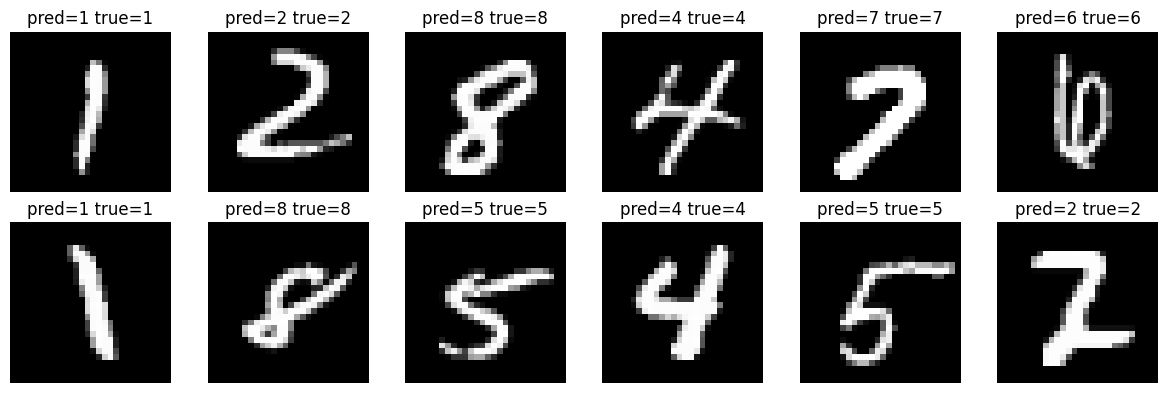

In [21]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the model and x_test, y_test from Exercise 3
# To-Do: select N samples from x_test by using np.random.choice
idx = np.random.choice(len(x_test), size=12, replace=False)
x_vis = x_test[idx]
y_true = y_test[idx]

# To-Do: get predictions
y_prob = model.predict(x_vis)
y_pred = np.argmax(y_prob, axis=1)

#plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}" )
    plt.axis("off")
plt.tight_layout()
plt.show()
